<img src="https://github.com/mariabda2/intro_data_2026/blob/main/sesiones_practicas/imgs/banner_fcd.jpg?raw=1" alt="bannersp" width="1100"  height="150">

## <span style="color:#2F749F;"><strong>📦 Sesión práctica 4: Detección de datos atípicos</strong></span>
---
<p align="right">
  <a href="https://github.com/mariabda2/intro_data_2026/blob/main/sesiones_practicas/sp_4_maria_bernarda_salazar.ipynb?clone=true" target="_blank">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Abrir en Colab"/>
  </a>
</p>


## <span style="color:black;"><strong>Datos del estudiante</strong></span>

Relacione sus datos y los del compañero de trabajo

* Natalia Bernal Gutiérrez
* Julián Camilo Carvajal Mellizo


# <span style="color:#2F749F;"><strong>Ejercicio 1: Intervalo IQR</strong></span>

A partir de siguiente código:

1. Ajusta el código para mejorar la interpretación de la gráfica. Mínimo debes:
   - Indicar los nombres de los ejes
   - Incluir legenda para comprender lo que esté incluído en la gráfica
2. Generar máximo 5 líneas de análisis sobre lo que observas en términos de defición de atípicos sobre tú gráfica final

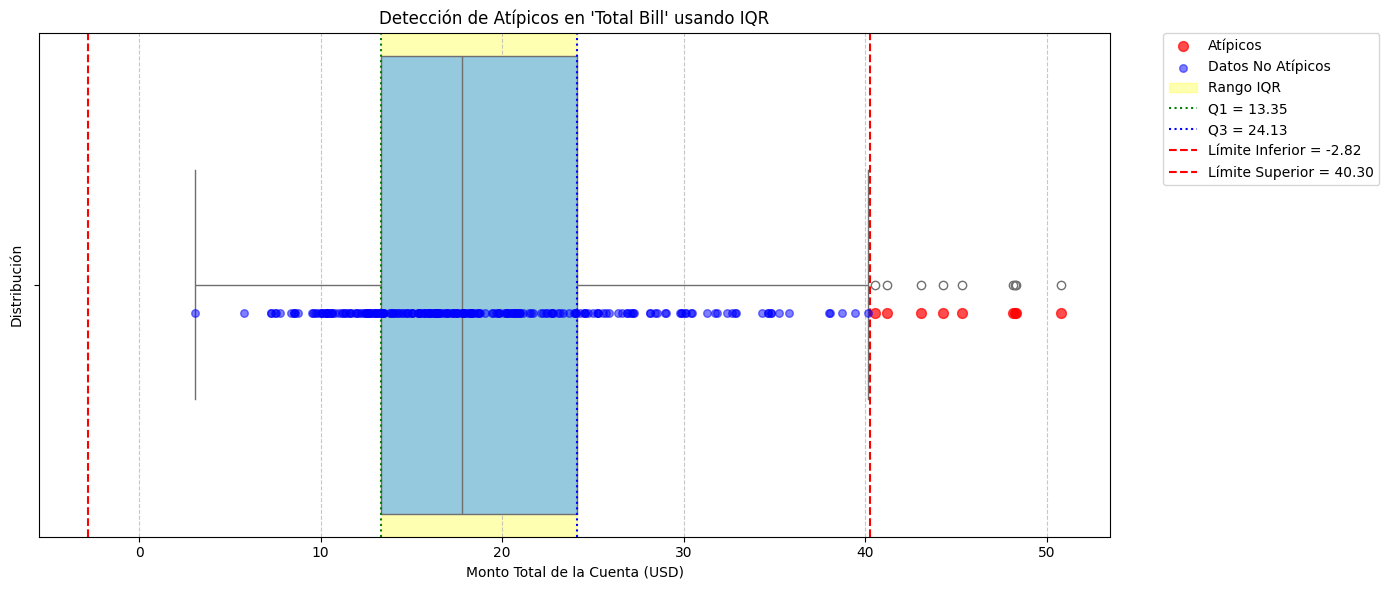

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

tips = sns.load_dataset("tips")
total_bill = tips["total_bill"].values
Q1, Q3 = np.percentile(total_bill, [25, 75])
IQR = Q3 - Q1
lim_inf = Q1 - 1.5 * IQR
lim_sup = Q3 + 1.5 * IQR
data_a = total_bill[(total_bill < lim_inf) | (total_bill > lim_sup)]
data_b = total_bill[(total_bill >= lim_inf) & (total_bill <= lim_sup)]

plt.figure(figsize=(14,6)) # Aumentamos el ancho de la figura para la leyenda
sns.boxplot(x=total_bill, color='skyblue')
# Añadimos etiquetas a los puntos para la leyenda
plt.scatter(data_a, [0.05]*len(data_a), color="red", s=50, alpha=0.7, label="Atípicos")
plt.scatter(data_b, [0.05]*len(data_b), color="blue", s=30, zorder=5, alpha=0.5, label="Datos No Atípicos")

# Resaltar el Rango Intercuartílico (IQR)
plt.axvspan(Q1, Q3, color='yellow', alpha=0.3, label='Rango IQR')
# Añadir líneas para Q1 y Q3
plt.axvline(Q1, color='green', linestyle=':', label=f'Q1 = {Q1:.2f}')
plt.axvline(Q3, color='blue', linestyle=':', label=f'Q3 = {Q3:.2f}')
# Añadir líneas para los límites del IQR
plt.axvline(lim_inf, color='red', linestyle='--', label=f'Límite Inferior = {lim_inf:.2f}')
plt.axvline(lim_sup, color='red', linestyle='--', label=f'Límite Superior = {lim_sup:.2f}')

plt.xlabel("Monto Total de la Cuenta (USD)") # Nombre del eje X
plt.ylabel("Distribución") # Nombre del eje Y
plt.title("Detección de Atípicos en 'Total Bill' usando IQR") # Título para mayor claridad
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.) # Movemos la leyenda a la derecha del gráfico
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

En la figura se puede observar una diferencia en los bigotes del boxplot, siendo más grande el que apunta al límite superior. Por otro lado, observamos que no existen datos atípicos en el límite inferior, lo que podría ser una señal la existencia de un consumo mínimo en el restaurante. Del mismo modo, podemos observar que todos los valores atípicos son valores altos, lo que indica que cuentas excesivamente costosas no son comunes, y sería necesario comparar con otras variables para establecer una posible causa (platos exclusivos, mesas con mayor número de comensales, celebraciones especiales, etc)





# <span style="color:#2F749F;"><strong>Ejercicio 2: Graficos de dispersión</strong></span>

A partir de siguiente código:

1. Ajusta el código para mejorar la interpretación de la gráfica. Mínimo debes:
   - Indicar los nombres de los ejes
   - Incluir legenda para comprender lo que esté incluído en la gráfica
2. Generar máximo 5 líneas de análisis sobre lo que observas en términos de defición de atípicos sobre tú gráfica final

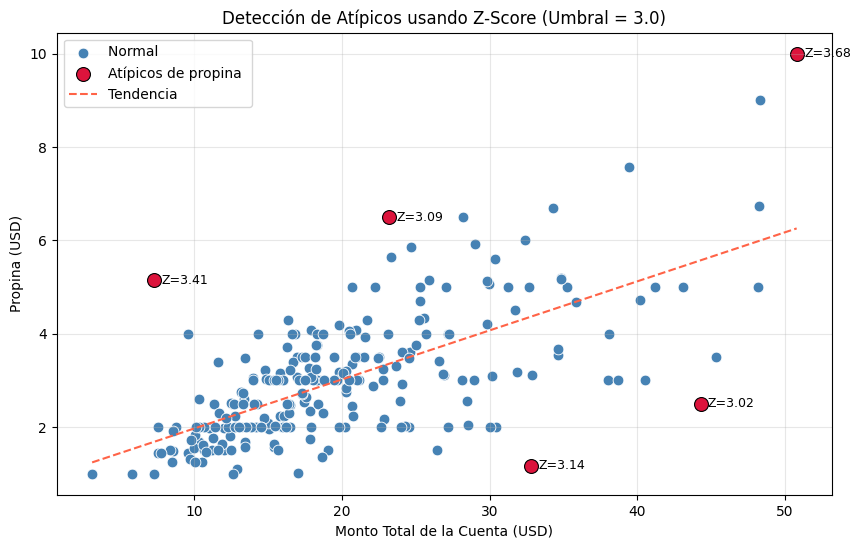

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats # Para calcular el Z-score fácilmente

# 1. Cargar datos
tips = sns.load_dataset("tips")
x = tips["total_bill"]
y = tips["tip"]

# 2. Calcular la línea de tendencia y los residuales
m, b = np.polyfit(x, y, 1)
y_pred = m * x + b
residuales = y - y_pred

# 3. Calcular el Z-Score de los residuales
# El Z-score nos dice qué tan lejos está cada punto de la línea en unidades de desviación estándar
z_scores = np.abs(stats.zscore(residuales))

# Definimos el umbral (Threshold)
umbral = 3.0
atipicos = z_scores > umbral

# 4. Graficar
plt.figure(figsize=(10, 6))

# Puntos normales
sns.scatterplot(x=x[~atipicos], y=y[~atipicos], color="steelblue", label="Normal ", s=60)

# Puntos atípicos detectados por Z-Score
sns.scatterplot(x=x[atipicos], y=y[atipicos], color="crimson", label=f"Atípicos de propina ", s=100, edgecolor="black")

# Línea de tendencia
x_range = np.linspace(x.min(), x.max(), 100)
plt.plot(x_range, m * x_range + b, color="tomato", linestyle="--", label="Tendencia")

# 5. Anotar los Z-scores en los puntos más extremos para ver el cálculo
for i in np.where(atipicos)[0]:
    plt.text(x.iloc[i]+0.5, y.iloc[i], f"Z={z_scores[i]:.2f}", fontsize=9, verticalalignment='center')

plt.title(f"Detección de Atípicos usando Z-Score (Umbral = {umbral})")
plt.xlabel("Monto Total de la Cuenta (USD)")
plt.ylabel("Propina (USD)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

En la gráfica se observa que existe una correlación positiva clara entre el monto de la cuenta y la propina, lo que podría indicar que gran parte de los clientes siguen la "regla" de dejar un porcentaje cómo propina (Algo más del 15% del total de la cuenta cómo más o menos se observa en la gráfica) Esto significa que, por lo general, a medida que el cliente gasta más en su consumo, el monto de la propina también aumenta.

Sin embargo, se puede observar que el monto de la propina se dispersa un poco a medida que incremente el monto total de la cuenta. Si bien sigue creciendo ya no es tan clara la relación. También se observa que los valores atípicos están presentes tanto en montos bajos de la cuenta, cómo en montos elevados, y puede ser por clientes que dejan más propina de lo esperado, así cómo por esos que dejan mucho menos de lo que se espera en una cuenta de gran tamaño.


# <span style="color:#2F749F;"><strong>Ejercicio 3: Histogramas y funciones de densidad</strong></span>

A partir de siguiente código:

1. Ajusta el código para mejorar la interpretación de la gráfica. Mínimo debes:
   - Indicar los nombres de los ejes
   - Incluir legenda para comprender lo que esté incluído en la gráfica
2. Generar máximo 5 líneas de análisis sobre lo que observas en términos de defición de atípicos sobre tú gráfica final

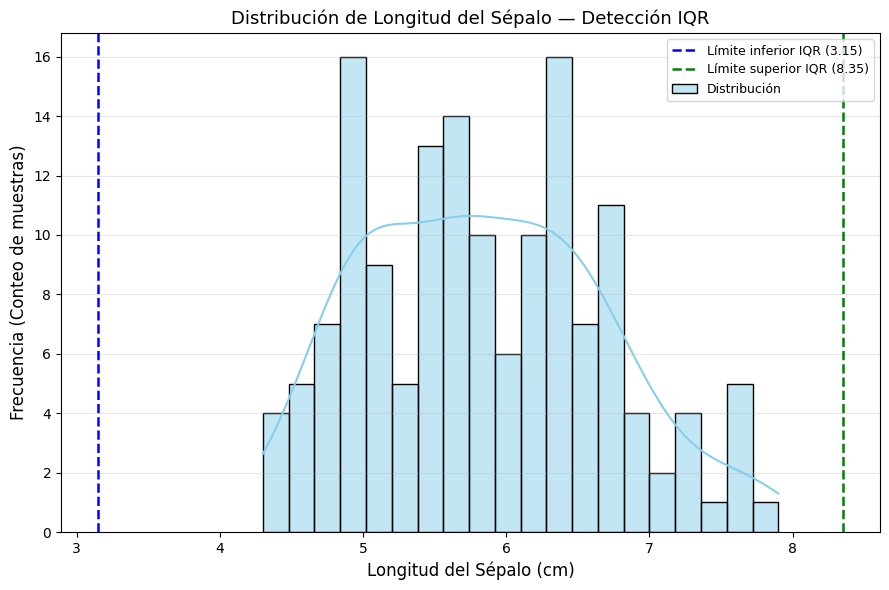

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

iris = sns.load_dataset("iris")
x = iris["sepal_length"].values

# --- Detección de atípicos con IQR ---
Q1 = np.percentile(x, 25)
Q3 = np.percentile(x, 75)
IQR = Q3 - Q1
limite_inf = Q1 - 1.5 * IQR
limite_sup = Q3 + 1.5 * IQR

outliers = x[(x < limite_inf) | (x > limite_sup)]
normales  = x[(x >= limite_inf) & (x <= limite_sup)]

# --- Gráfica ---
fig, ax = plt.subplots(figsize=(9, 6))

sns.histplot(x=x, bins=20, kde=True, color="skyblue",
             ax=ax, label="Distribución")

# Líneas de límites IQR
ax.axvline(limite_inf, color="blue", linestyle="--", linewidth=1.8,
           label=f"Límite inferior IQR ({limite_inf:.2f})")
ax.axvline(limite_sup, color="green", linestyle="--", linewidth=1.8,
           label=f"Límite superior IQR ({limite_sup:.2f})")

# Marcar atípicos individuales en el eje X
for val in outliers:
    ax.scatter(val, 0, color="red", s=80, zorder=5, marker="^")
    ax.annotate(f"{val:.1f}", (val, 0.3), ha="center",
                fontsize=9, color="darkred")

ax.set_xlabel("Longitud del Sépalo (cm)", fontsize=12)
ax.set_ylabel("Frecuencia (Conteo de muestras)", fontsize=12)
ax.set_title("Distribución de Longitud del Sépalo — Detección IQR", fontsize=13)
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

Al analizar la gráfica, lo primero que observamos es que hay algunos "picos", y no se ve cómo una distribución completamente normal. Si consideramos el contexto del problema podemos notar que hay 3 tipos diferentes de flor iris, y en la variable graficada ("sepal_length") no se están separando, lo cuál posiblemente sesgue el análisis, pues es probable que cada especie tenga una longitud diferente.

Un análisis más riguroso incluiría separar las flores por su especie o subespecie y hacer el análisis de forma individual para esta variabe.

# <span style="color:#2F749F;"><strong>Ejercicio 4: Z-Score</strong></span>

A partir de siguiente código:

1. Ajusta el código para mejorar la interpretación de la gráfica. Mínimo debes:
   - Indicar los nombres de los ejes
   - Incluir legenda para comprender lo que esté incluído en la gráfica
2. Generar máximo 5 líneas de análisis sobre lo que observas en términos de defición de atípicos sobre tú gráfica final

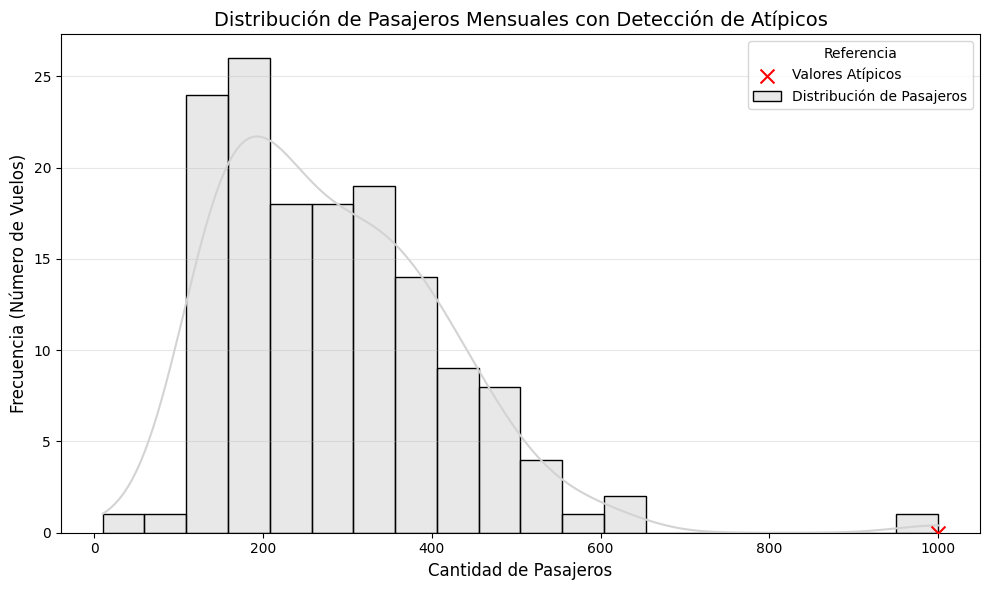

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import zscore

# 1. Cargar y preparar datos
flights = sns.load_dataset("flights")
x = flights["passengers"].values

# Añadimos valores extremos para forzar atípicos
# (10 es muy bajo y 1000 es muy alto para este dataset)
x = np.append(x, [10, 1000])

# 2. Calcular Z-score y detectar atípicos
z_scores = zscore(x)
es_atipico = np.abs(z_scores) > 3

plt.figure(figsize=(10, 6))

# 3. Graficar Histograma y KDE
sns.histplot(x=x, bins=20, kde=True, color="lightgray", label="Distribución de Pasajeros")

# 4. Graficar los puntos atípicos en la base (y=0)
# Cambié marker=" " por marker="x" para que se vean
plt.scatter(x[es_atipico], np.zeros_like(x[es_atipico]),
            color="red", s=100, marker="x", label="Valores Atípicos", zorder=5)

# 5. Nombres de los ejes
plt.xlabel("Cantidad de Pasajeros", fontsize=12)
plt.ylabel("Frecuencia (Número de Vuelos)", fontsize=12)

# 6. Título y Leyenda
plt.title("Distribución de Pasajeros Mensuales con Detección de Atípicos", fontsize=14)
plt.legend(loc="upper right", title="Referencia")

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

La gráfica del histograma nos permite ver que la variable tiene una distribución aproximadamente normal y se nota una cola a la derecha. Este atípico hace referencia a una cantidad de pasajeros mensuales extremadamente alta y haría falta revisar más datos para comprender si se puede tratar de un posible error de medición o digitación o incluso algún evento extraordinario que pudo haber ocurrido en algún momento.

# <span style="color:#2F749F;"><strong>Ejercicio 5: K-means</strong></span>

A partir de siguiente código:

1. Ajusta el código para mejorar la interpretación de la gráfica. Mínimo debes:
   - Indicar los nombres de los ejes
   - Incluir legenda para comprender lo que esté incluído en la gráfica
2. Generar máximo 5 líneas de análisis sobre lo que observas en términos de defición de atípicos sobre tú gráfica final

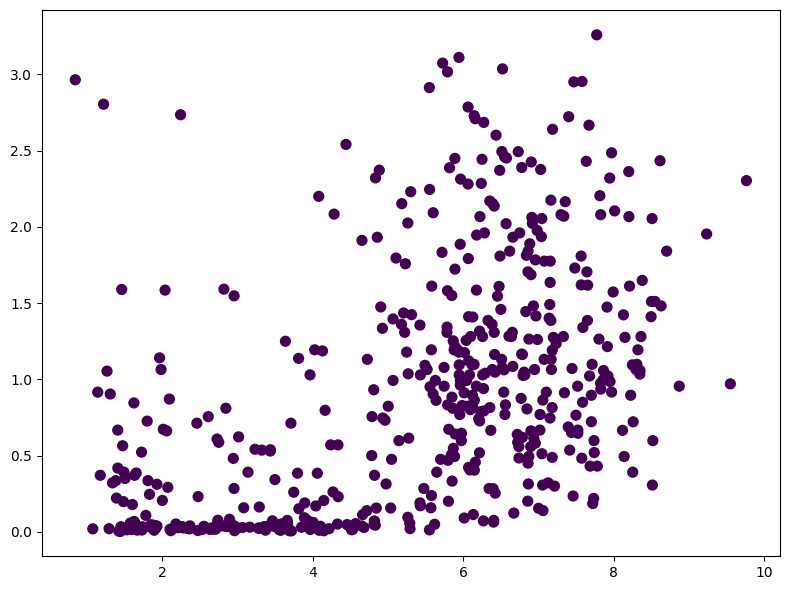

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import numpy as np

planets = sns.load_dataset("planets").dropna(subset=["orbital_period", "mass"])
X = planets[["orbital_period", "mass"]].values
X = np.log1p(X)

kmeans = KMeans(n_clusters=1, random_state=42).fit(X)
labels = kmeans.labels_

plt.figure(figsize=(8,6))
plt.scatter(X[:,0], X[:,1], c=labels, cmap="viridis", s=50)
plt.tight_layout()
plt.show()
